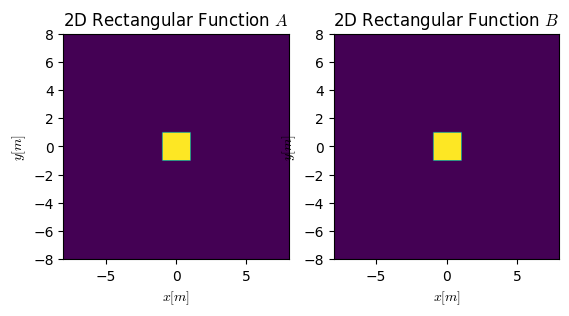

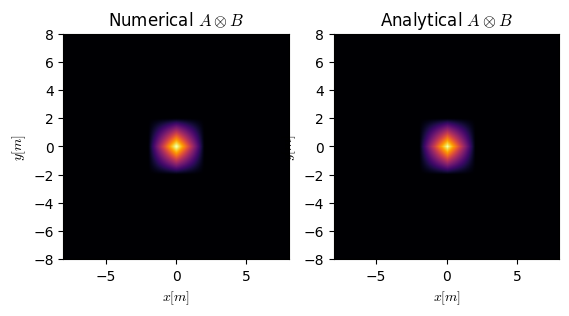

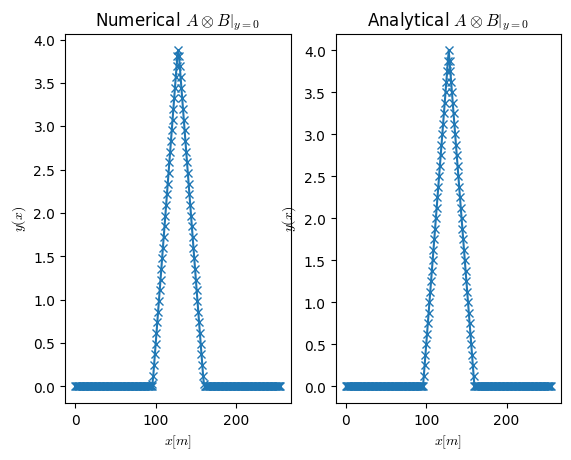

In [ ]:
"""
2D Convolution of two rectangular functions using the Fourier method. A Numerical and Analytical Comparison.
"""

import numpy as np
import matplotlib.pyplot as plt
from optprop.aperture_functions import rect, tri
from optprop.ft_functions import myconv2

N = 256
L = 16
delta = L/N
F = 1/L # 1/(N*delta)
x = np.arange(-N/2,N/2,1) * delta
x,y = np.meshgrid(x,x)
w = 2

A = rect(x/w) * rect(y/w)
B = A
C = myconv2(A,B,delta)
C_cont = (w**2)*tri(x/w)*tri(y/w)

fig,ax = plt.subplots(1,2)
ax[0].imshow(A,extent=[-L/2,L/2,-L/2,L/2],aspect='equal')
ax[0].set_xlabel(r"$x[m]$",math_fontfamily='cm')
ax[0].set_ylabel(r"$y[m]$",math_fontfamily='cm')
ax[0].set_title(r"2D Rectangular Function $A$",math_fontfamily='cm')

ax[1].imshow(B,extent=[-L/2,L/2,-L/2,L/2],aspect='equal')
ax[1].set_xlabel(r"$x[m]$",math_fontfamily='cm')
ax[1].set_ylabel(r"$y[m]$",math_fontfamily='cm')
ax[1].set_title(r"2D Rectangular Function $B$",math_fontfamily='cm')

fig,ax = plt.subplots(1,2)
ax[0].imshow(np.abs(C),extent=[-L/2,L/2,-L/2,L/2],cmap='inferno')
ax[0].set_xlabel(r"$x[m]$",math_fontfamily='cm')
ax[0].set_ylabel(r"$y[m]$",math_fontfamily='cm')
ax[0].set_title(r"Numerical $A \otimes B$",math_fontfamily='cm')
ax[1].imshow(C_cont,extent=[-L/2,L/2,-L/2,L/2],cmap='inferno')
ax[1].set_xlabel(r"$x[m]$",math_fontfamily='cm')
ax[1].set_ylabel(r"$y[m]$",math_fontfamily='cm')
ax[1].set_title(r"Analytical $A \otimes B$",math_fontfamily='cm')

fig,ax = plt.subplots(1,2)
ax[0].plot(np.abs(C)[N//2,:],marker='x')
ax[0].set_xlabel(r"$x[m]$",math_fontfamily='cm')
ax[0].set_ylabel(r"$y(x)$",math_fontfamily='cm')
ax[0].set_title(r"Numerical $\left. A \otimes B \right|_{y=0}$",math_fontfamily='cm')
ax[1].plot(C_cont[N//2,:],marker='x')
ax[1].set_xlabel(r"$x[m]$",math_fontfamily='cm')
ax[1].set_ylabel(r"$y(x)$",math_fontfamily='cm')
ax[1].set_title(r"Analytical $\left. A \otimes B \right|_{y=0}$",math_fontfamily='cm')
plt.show()

Incorrect results arose from `myconv2`. Incorrect logic during `C = ift2(ft2(A,delta) * ft2(B,delta), 1/(N*delta))`. There seems to be some floating point error.